In [7]:
# Load data and basic EDA for toxicity classification
import pandas as pd
import numpy as np
from tqdm import tqdm

df = pd.read_csv("./Downloads/data.csv")

print(df.head())
print(df.describe(include='all'))
print(df.isna().sum().head())
print(df.dtypes.head())

   MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  MATS3e  \
0  0.0908         0  0.0075  0.0173                0        0.0 -0.0436   
1  0.0213         0  0.1144 -0.0410                0        0.0  0.1231   
2  0.0018         0 -0.0156 -0.0765                2        0.0 -0.1138   
3 -0.0251         0 -0.0064 -0.0894                3        0.0 -0.0747   
4  0.0135         0  0.0424 -0.0353                0        0.0 -0.0638   

   MATS3c  minHBint2  MATS3m  ...   WTPT-4   WTPT-5  ETA_EtaP_L  ETA_EtaP_F  \
0  0.0409        0.0  0.1368  ...   0.0000   0.0000      0.1780      1.5488   
1 -0.0316        0.0  0.1318  ...   8.8660  19.3525      0.1739      1.3718   
2 -0.1791        0.0  0.0615  ...   5.2267  27.8796      0.1688      1.4395   
3 -0.1151        0.0  0.0361  ...   7.7896  24.7336      0.1702      1.4654   
4  0.0307        0.0  0.0306  ...  12.3240  19.7486      0.1789      1.4495   

   ETA_EtaP_B  nT5Ring  SHdNH  ETA_dEpsilon_C  MDEO-22     Class  
0      

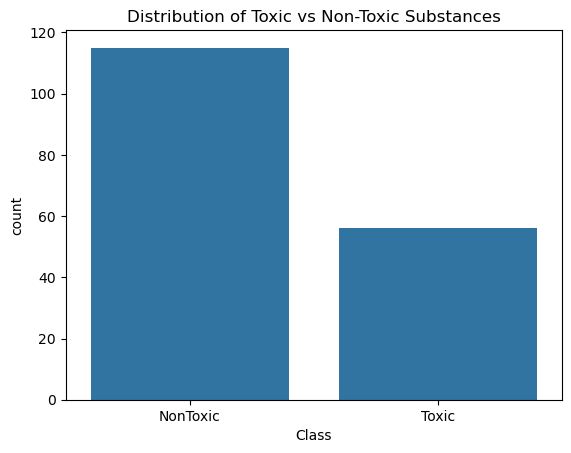

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("./Downloads/data.csv")

sns.countplot(x="Class", data=df)
plt.title("Distribution of Toxic vs Non-Toxic Substances")
plt.show()


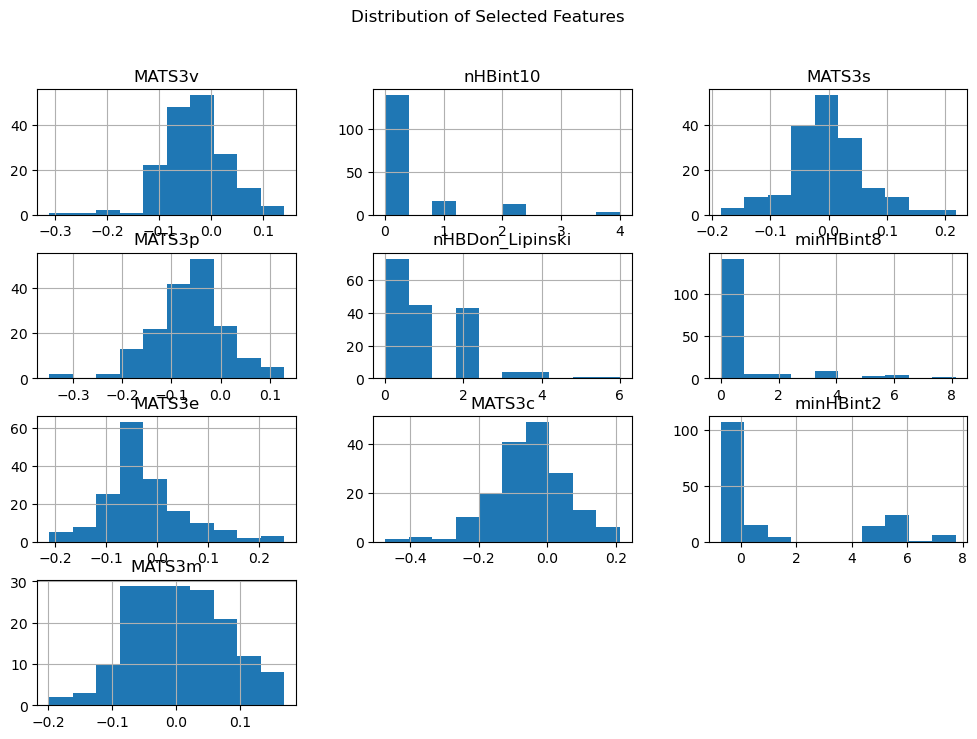

In [8]:
df.iloc[:, :10].hist(figsize=(12,8))
plt.suptitle("Distribution of Selected Features")
plt.show()


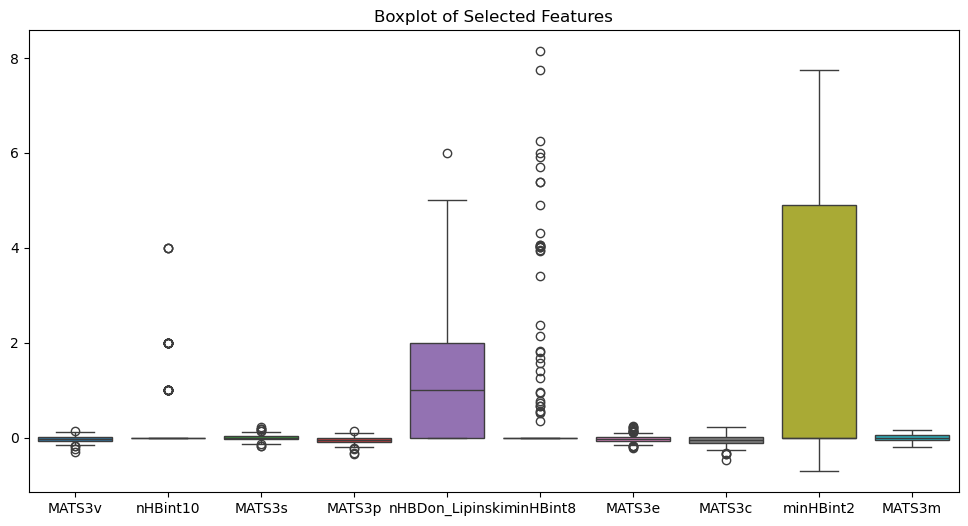

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.iloc[:, :10])
plt.title("Boxplot of Selected Features")
plt.show()

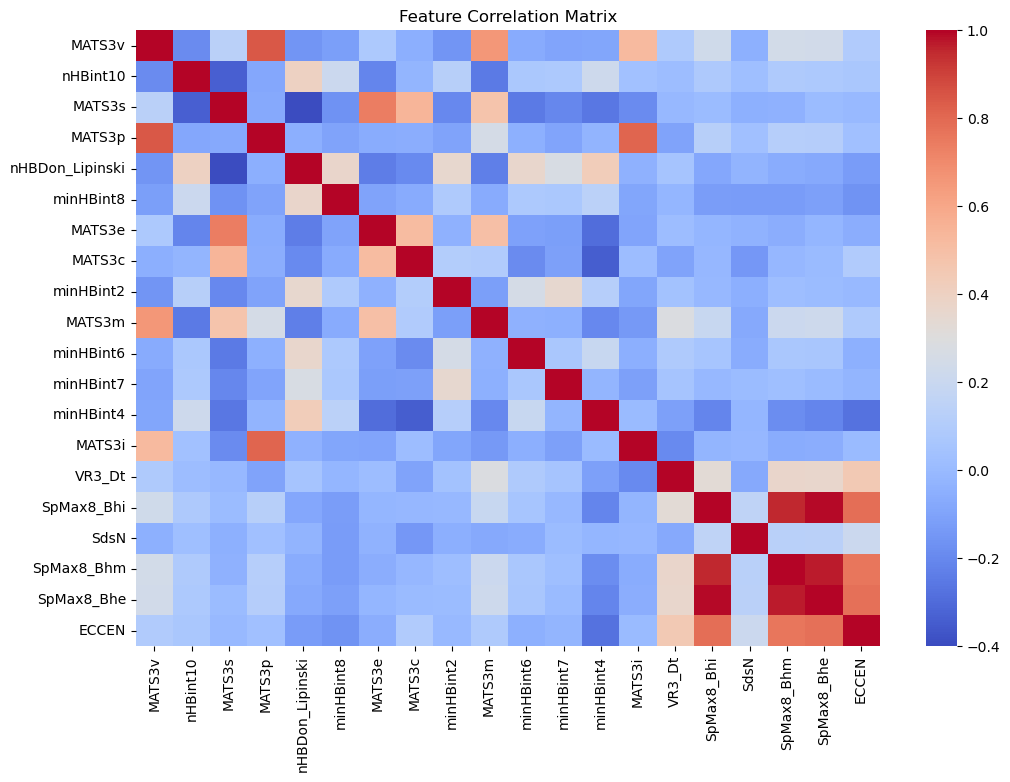

In [12]:
subset = df.iloc[:, :20]

corr = subset.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

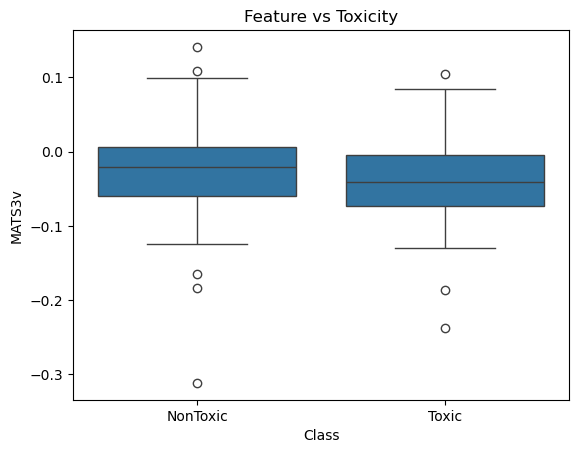

In [14]:
sns.boxplot(x="Class", y=df.columns[0], data=df)
plt.title("Feature vs Toxicity")
plt.show()

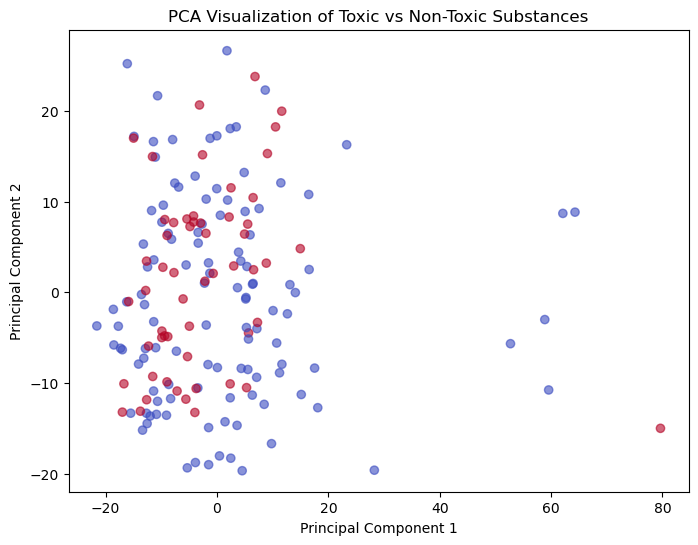

In [24]:
# Cell 5: PCA visualization

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df.drop("Class", axis=1)
y = df["Class"].map({"NonToxic":0, "Toxic":1})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0],
            X_pca[:,1],
            c=y,
            cmap="coolwarm",
            alpha=0.6)

plt.title("PCA Visualization of Toxic vs Non-Toxic Substances")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [26]:
# Cell 6: Feature correlation with toxicity

df_encoded = df.copy()

df_encoded["Class"] = df_encoded["Class"].map({"NonToxic":0, "Toxic":1})

corr_target = df_encoded.corr()["Class"].drop("Class")
corr_target_sorted = corr_target.abs().sort_values(ascending=False)

print(corr_target_sorted.head(10))

EE_Dt         0.214785
C2SP2         0.189377
AATSC7p       0.165491
SpDiam_Dt     0.165033
MLogP         0.164396
MATS7p        0.163581
nAcid         0.160158
nwHBa         0.157351
GATS7v        0.156486
SpMin4_Bhi    0.155733
Name: Class, dtype: float64


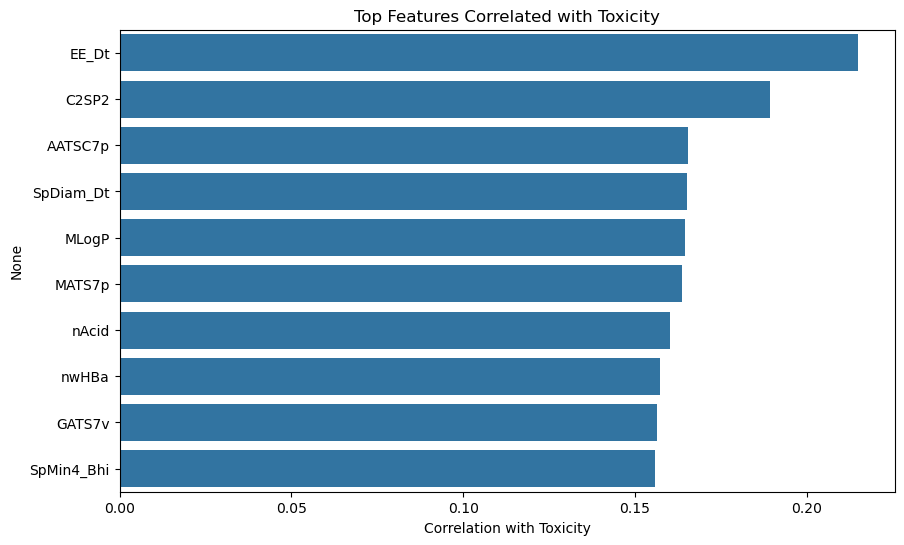

In [28]:
# Cell 7: Top correlated features with toxicity

top_features = corr_target_sorted.head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_features.values,
            y=top_features.index)

plt.title("Top Features Correlated with Toxicity")
plt.xlabel("Correlation with Toxicity")

plt.show()

In [34]:
# Data preparation cell

import pandas as pd
from sklearn.feature_selection import VarianceThreshold

# load dataset
df = pd.read_csv(r"C:\Users\hp\Downloads\data.csv")

# encode target
df["Class"] = df["Class"].map({"NonToxic":0, "Toxic":1})

# split features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# remove constant features
var_filter = VarianceThreshold(0.0)
X_var = var_filter.fit_transform(X)

print("Shape after removing constant features:", X_var.shape)

Shape after removing constant features: (171, 1203)


Shape after removing constant features: (171, 1203)

Random Forest Results with SMOTE
Best Parameters: {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
Best CV F1 Score: 0.3268295739348371

Test Set Results:
Accuracy: 0.6857142857142857
Precision: 0.5
Recall: 0.09090909090909091
F1 Score: 0.15384615384615385

Classification Report
              precision    recall  f1-score   support

   Non-Toxic       0.70      0.96      0.81        24
       Toxic       0.50      0.09      0.15        11

    accuracy                           0.69        35
   macro avg       0.60      0.52      0.48        35
weighted avg       0.64      0.69      0.60        35



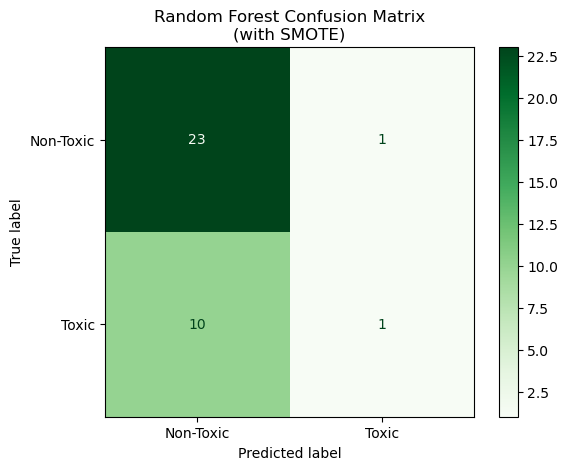

In [43]:
# Data preparation cell

import pandas as pd
from sklearn.feature_selection import VarianceThreshold

# load dataset
df = pd.read_csv(r"C:\Users\hp\Downloads\data.csv")

# encode target
df["Class"] = df["Class"].map({"NonToxic":0, "Toxic":1})

# split features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# remove constant features
var_filter = VarianceThreshold(0.0)
X_var = var_filter.fit_transform(X)

print("Shape after removing constant features:", X_var.shape)
# Random Forest Model with SMOTE (Alternative approach)

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X_var, y, test_size=0.2, random_state=42, stratify=y
)

# ===== CLASS IMBALANCE HANDLING WITH SMOTE =====
# Create pipeline with SMOTE and Random Forest
rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),  # ADDED: Oversample minority class
    ('rf', RandomForestClassifier(random_state=42))
])

# hyperparameter grid (adjusted for pipeline)
rf_param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": [2, 5]
}

# Use stratified k-fold cross-validation
rf_grid = GridSearchCV(
    rf_pipe,
    rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1",  # Use F1 score for imbalanced data
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_

y_pred_rf = rf_best.predict(X_test)

print("\n" + "="*50)
print("Random Forest Results with SMOTE")
print("="*50)
print("Best Parameters:", rf_grid.best_params_)
print("Best CV F1 Score:", rf_grid.best_score_)
print("\nTest Set Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_rf, zero_division=0))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf, target_names=["Non-Toxic", "Toxic"], zero_division=0))

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                              display_labels=["Non-Toxic", "Toxic"])

disp.plot(cmap="Greens")

plt.title("Random Forest Confusion Matrix\n(with SMOTE)")
plt.show()






SVM Best Parameters: {'svc__C': 0.5, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Accuracy: 0.6857142857142857
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Classification Report
              precision    recall  f1-score   support

           0       0.69      1.00      0.81        24
           1       0.00      0.00      0.00        11

    accuracy                           0.69        35
   macro avg       0.34      0.50      0.41        35
weighted avg       0.47      0.69      0.56        35



C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_

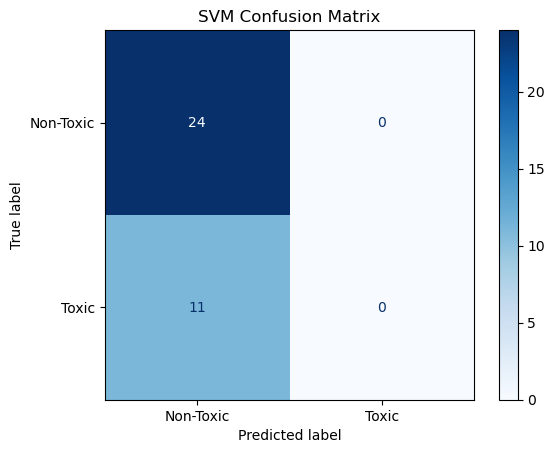

In [38]:
# SVM Model

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC())
])

svm_param_grid = {
    "svc__C": [0.5, 1, 5, 10],
    "svc__gamma": ["scale", 0.01, 0.1],
    "svc__kernel": ["rbf"]
}

svm_grid = GridSearchCV(
    svm_pipe,
    svm_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

svm_best = svm_grid.best_estimator_

y_pred_svm = svm_best.predict(X_test)

print("SVM Best Parameters:", svm_grid.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))

print("\nClassification Report")
print(classification_report(y_test, y_pred_svm))

cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm,
                              display_labels=["Non-Toxic", "Toxic"])

disp.plot(cmap="Blues")

plt.title("SVM Confusion Matrix")
plt.show()

CLASS IMBALANCE DIAGNOSIS
NonToxic (0): 115 samples
Toxic (1):    56 samples
Imbalance ratio: 2.05:1

Class weights: NonToxic=0.75, Toxic=1.51

MODEL 1: Logistic Regression with Class Weights

MODEL 2: Random Forest with SMOTE

MODEL 3: XGBoost with Undersampling

MODEL 4: SVM with SMOTE + Tomek Links

MODEL 5: KNN with ADASYN

MODEL COMPARISON ON TEST SET

Logistic Regression (Weighted):
  Accuracy:  0.6286
  Precision: 0.4000
  Recall:    0.3636
  F1 Score:  0.3810
  Toxic predictions: 10

Random Forest (SMOTE):
  Accuracy:  0.6571
  Precision: 0.3333
  Recall:    0.0909
  F1 Score:  0.1429
  Toxic predictions: 3

XGBoost (Undersampling):
  Accuracy:  0.7143
  Precision: 0.5385
  Recall:    0.6364
  F1 Score:  0.5833
  Toxic predictions: 13

SVM (SMOTE+Tomek):
  Accuracy:  0.3429
  Precision: 0.3235
  Recall:    1.0000
  F1 Score:  0.4889
  Toxic predictions: 34

KNN (ADASYN):
  Accuracy:  0.4286
  Precision: 0.2353
  Recall:    0.3636
  F1 Score:  0.2857
  Toxic predictions: 17

SUM

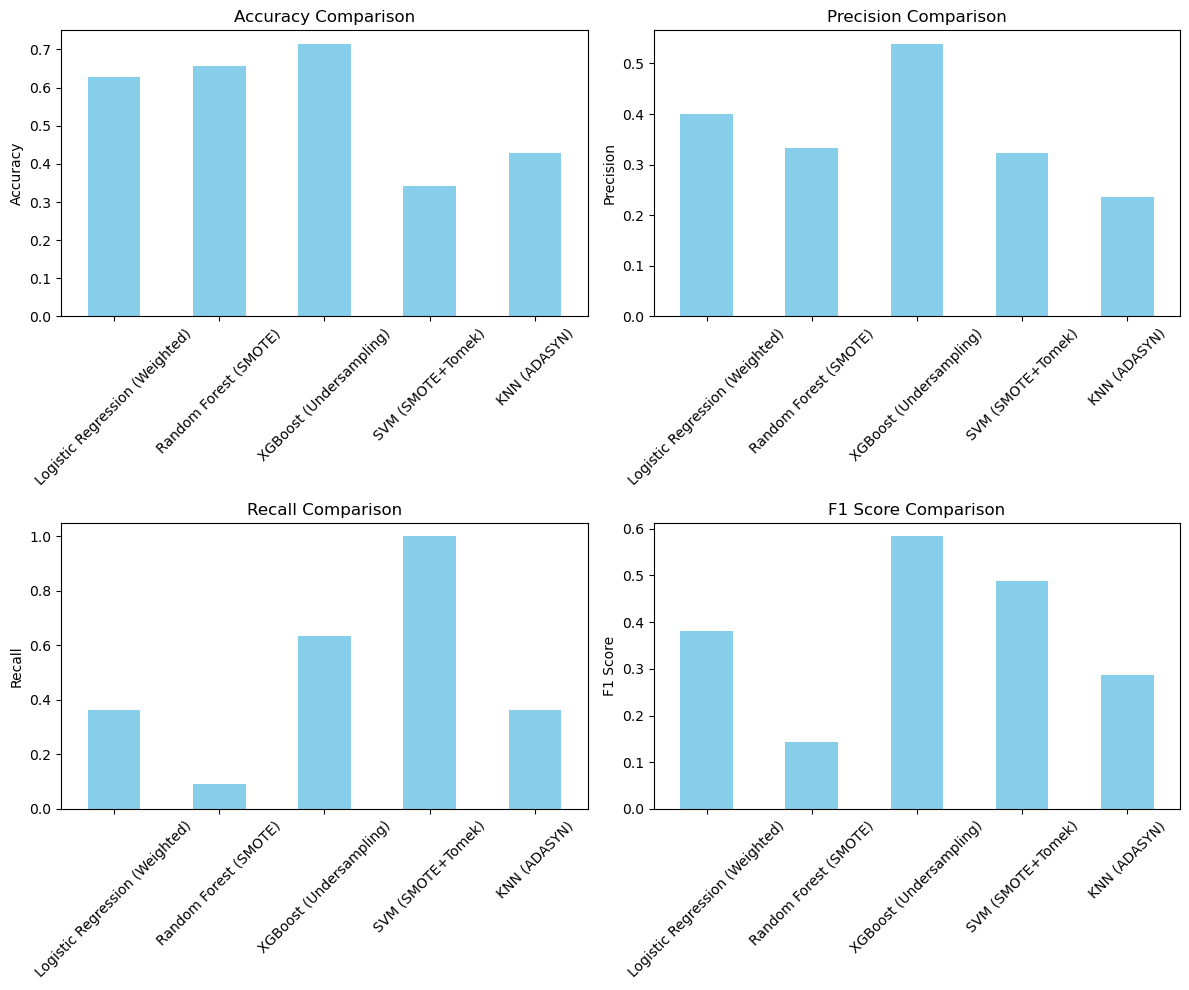


RECOMMENDATION
Best model by F1 Score: XGBoost (Undersampling)
  F1 Score: 0.5833
  Recall:   0.6364
  Precision: 0.5385


In [37]:
# Universal pre-modelling framework for ANY model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter

# Load your data
data = pd.read_csv("./Downloads/data.csv")
X = data.drop('Class', axis=1)
y = (data['Class'] == 'Toxic').astype(int)

# ============================================
# UNIVERSAL PRE-MODELLING STEPS
# ============================================

# 1. DIAGNOSE IMBALANCE
print("="*60)
print("CLASS IMBALANCE DIAGNOSIS")
print("="*60)
class_counts = pd.Series(y).value_counts()
print(f"NonToxic (0): {class_counts[0]} samples")
print(f"Toxic (1):    {class_counts[1]} samples")
print(f"Imbalance ratio: {class_counts[0]/class_counts[1]:.2f}:1")

# 2. STRATIFIED SPLIT (ALWAYS DO THIS!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. COMPUTE CLASS WEIGHTS (works for ANY model)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"\nClass weights: NonToxic={weight_dict[0]:.2f}, Toxic={weight_dict[1]:.2f}")

# ============================================
# APPLY TO DIFFERENT MODELS
# ============================================

# Dictionary to store all model results
results = {}

# Create cross-validation strategy (same for all models)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --------------------------------------------
# OPTION 1: Class Weights (works for most models)
# --------------------------------------------
print("\n" + "="*60)
print("MODEL 1: Logistic Regression with Class Weights")
print("="*60)
from sklearn.linear_model import LogisticRegression

lr_weighted = LogisticRegression(
    class_weight=weight_dict,
    max_iter=1000,
    random_state=42
)

# Parameter grid
lr_params = {'C': [0.01, 0.1, 1, 10]}

lr_grid = GridSearchCV(
    lr_weighted, lr_params, 
    scoring='f1', cv=cv, n_jobs=-1
)
lr_grid.fit(X_train, y_train)
results['Logistic Regression (Weighted)'] = lr_grid.best_estimator_

# --------------------------------------------
# OPTION 2: SMOTE + Any Model
# --------------------------------------------
print("\n" + "="*60)
print("MODEL 2: Random Forest with SMOTE")
print("="*60)
from sklearn.ensemble import RandomForestClassifier

# Pipeline with SMOTE + Random Forest
rf_smote_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

rf_params = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20, None],
    'rf__min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    rf_smote_pipe, rf_params,
    scoring='f1', cv=cv, n_jobs=-1
)
rf_grid.fit(X_train, y_train)
results['Random Forest (SMOTE)'] = rf_grid.best_estimator_

# --------------------------------------------
# OPTION 3: Undersampling + Any Model
# --------------------------------------------
print("\n" + "="*60)
print("MODEL 3: XGBoost with Undersampling")
print("="*60)
from xgboost import XGBClassifier

# Pipeline with Undersampling + XGBoost
xgb_under_pipe = ImbPipeline([
    ('undersample', RandomUnderSampler(random_state=42)),
    ('xgb', XGBClassifier(eval_metric='logloss', random_state=42))
])

xgb_params = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [4, 6],
    'xgb__learning_rate': [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    xgb_under_pipe, xgb_params,
    scoring='f1', cv=cv, n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
results['XGBoost (Undersampling)'] = xgb_grid.best_estimator_

# --------------------------------------------
# OPTION 4: SMOTE + Tomek Links + Any Model
# --------------------------------------------
print("\n" + "="*60)
print("MODEL 4: SVM with SMOTE + Tomek Links")
print("="*60)
from sklearn.svm import SVC

# Pipeline with SMOTE + Tomek + SVM
svm_smt_pipe = ImbPipeline([
    ('smt', SMOTETomek(random_state=42)),
    ('scaler', StandardScaler(with_mean=False)),
    ('svm', SVC(kernel='rbf', class_weight='balanced', random_state=42, probability=True))
])

svm_params = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.1, 0.01]
}

svm_grid = GridSearchCV(
    svm_smt_pipe, svm_params,
    scoring='f1', cv=cv, n_jobs=-1
)
svm_grid.fit(X_train, y_train)
results['SVM (SMOTE+Tomek)'] = svm_grid.best_estimator_

# --------------------------------------------
# OPTION 5: ADASYN (Alternative to SMOTE) + Any Model
# --------------------------------------------
print("\n" + "="*60)
print("MODEL 5: KNN with ADASYN")
print("="*60)
from sklearn.neighbors import KNeighborsClassifier

# Pipeline with ADASYN + KNN
knn_adasyn_pipe = ImbPipeline([
    ('adasyn', ADASYN(random_state=42)),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_params = {
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    knn_adasyn_pipe, knn_params,
    scoring='f1', cv=cv, n_jobs=-1
)
knn_grid.fit(X_train, y_train)
results['KNN (ADASYN)'] = knn_grid.best_estimator_

# ============================================
# COMPARE ALL MODELS
# ============================================
print("\n" + "="*60)
print("MODEL COMPARISON ON TEST SET")
print("="*60)

comparison_data = []
for name, model in results.items():
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    comparison_data.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Toxic Predicted': np.sum(y_pred)
    })
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  Toxic predictions: {np.sum(y_pred)}")

# Create comparison dataframe
comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
for i, metric in enumerate(metrics):
    ax = axes[i//2, i%2]
    comparison_df.plot(x='Model', y=metric, kind='bar', ax=ax, legend=False, color='skyblue')
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================
# CHOOSE THE BEST MODEL
# ============================================
print("\n" + "="*60)
print("RECOMMENDATION")
print("="*60)

best_f1 = comparison_df.loc[comparison_df['F1 Score'].idxmax()]
print(f"Best model by F1 Score: {best_f1['Model']}")
print(f"  F1 Score: {best_f1['F1 Score']:.4f}")
print(f"  Recall:   {best_f1['Recall']:.4f}")
print(f"  Precision: {best_f1['Precision']:.4f}")


Class distribution:
Class
NonToxic    115
Toxic        56
Name: count, dtype: int64

Training set size: (136, 1203)
Testing set size: (35, 1203)

Training XGBoost model...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

XGBoost Results
Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Best Cross-Validation Score: 0.6323
Accuracy: 0.6286
Precision: 0.2500
Recall: 0.0909
F1 Score: 0.1333

Classification Report
              precision    recall  f1-score   support

    NonToxic       0.68      0.88      0.76        24
       Toxic       0.25      0.09      0.13        11

    accuracy                           0.63        35
   macro avg       0.46      0.48      0.45        35
weighted avg       0.54      0.63      0.57        35



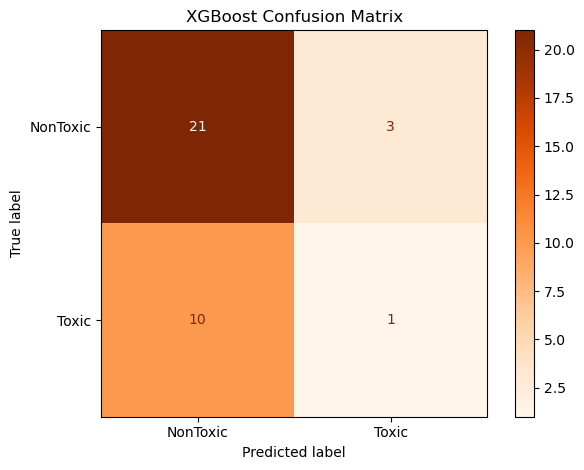

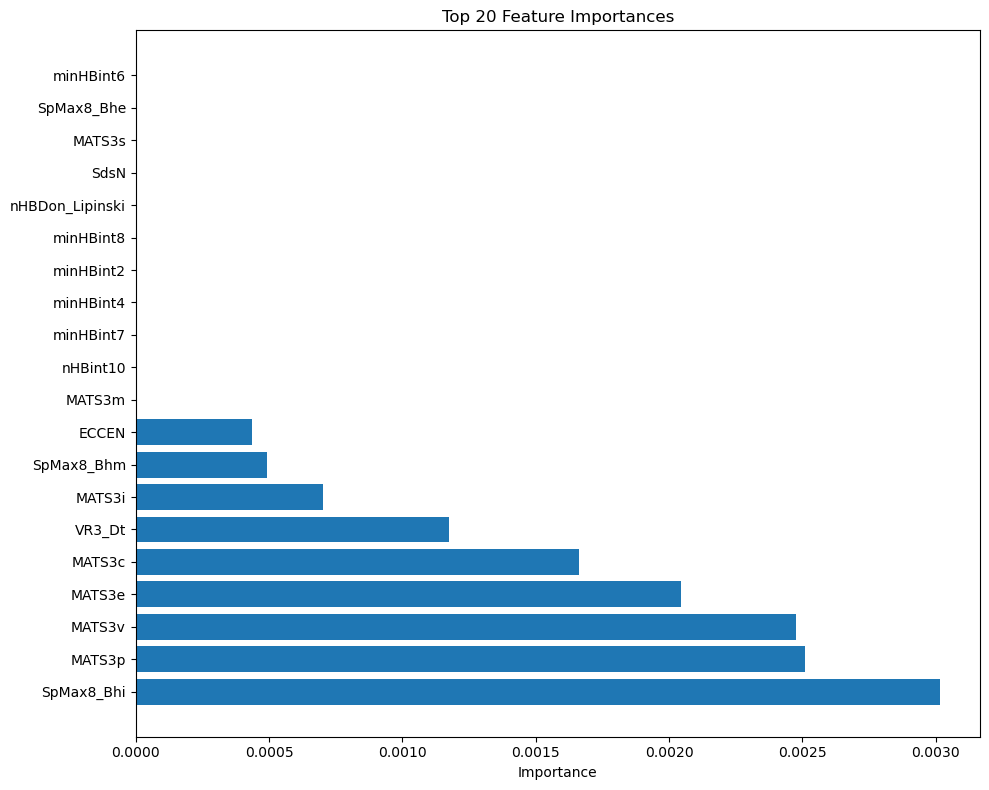

In [27]:
# XGBoost Model
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load your data
data = pd.read_csv("./Downloads/data.csv")

# Separate features and target
X = data.drop('Class', axis=1)  # 'Class' is the target column
y = data['Class']  # 'Class' contains 'Toxic' and 'NonToxic'

# Convert target to binary if needed (Toxic=1, NonToxic=0)
y_binary = (y == 'Toxic').astype(int)
print(f"\nClass distribution:\n{y.value_counts()}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# Initialize XGBoost classifier
xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

# Parameter grid for GridSearchCV
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1]
}

# Perform grid search
xgb_grid = GridSearchCV(
    xgb,
    xgb_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

# Fit the model
print("\nTraining XGBoost model...")
xgb_grid.fit(X_train, y_train)

# Get the best model
xgb_best = xgb_grid.best_estimator_

# Make predictions
y_pred_xgb = xgb_best.predict(X_test)

# Print results
print("\n" + "="*50)
print("XGBoost Results")
print("="*50)
print("Best Parameters:", xgb_grid.best_params_)
print(f"Best Cross-Validation Score: {xgb_grid.best_score_:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb):.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb, target_names=["NonToxic", "Toxic"]))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb,
                              display_labels=["NonToxic", "Toxic"])
disp.plot(cmap="Oranges")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

# Feature importance (optional)
if hasattr(xgb_best, 'feature_importances_'):
    # Get top 20 features
    feature_importance = pd.DataFrame({
        'feature': X.columns[:20],
        'importance': xgb_best.feature_importances_[:20]
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    plt.barh(feature_importance['feature'], feature_importance['importance'])
    plt.xlabel('Importance')
    plt.title('Top 20 Feature Importances')
    plt.tight_layout()
    plt.show()